# Quickbite jupyter notebook 

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [3]:
 # Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


### Loading the data

In [ ]:
# ============================================================================
# STEP 1: LOAD DATA
# ============================================================================
# This step loads all required Excel datasets into Pandas DataFrames.
# Each dataset represents either a dimension table or a fact table
# used later for analysis, joins, and KPI calculations.
# ============================================================================

# Display step progress in the console
print("\n[STEP 1] Loading data...")

# ----------------------------------------------------------------------------
# Define file paths for all datasets
# ----------------------------------------------------------------------------
# The dictionary key represents the logical dataset name used in Python.
# The dictionary value represents the actual Excel file name on disk.

# ----------------------------------------------------------------------------
file_paths = {
    'dim_customer': 'dim_customer2.xlsx',
    'dim_restaurant': 'dim_restaurant2.xlsx',
    'dim_menu_item': 'dim_menu_item2.xlsx',
    'fact_orders': 'fact_orders2.xlsx',
    'fact_order_items': 'fact_order_items2.xlsx',
    'fact_delivery_performance': 'fact_delivery_performance2.xlsx',
    'fact_ratings': 'fact_ratings2.xlsx'
}

# ----------------------------------------------------------------------------
# Create an empty dictionary to store all loaded DataFrames
# ----------------------------------------------------------------------------
# This allows us to dynamically load multiple files using a loop
# instead of writing repetitive pd.read_excel() statements.
# ----------------------------------------------------------------------------
datasets = {}

# ----------------------------------------------------------------------------
# Loop through each file path and load the Excel file
# ----------------------------------------------------------------------------
for dataset_name, file_path in file_paths.items():

    # Read the Excel file into a Pandas DataFrame
    datasets[dataset_name] = pd.read_excel(file_path)

    # Print confirmation message with row count for validation
    print(f"✓ {dataset_name}: {len(datasets[dataset_name]):,} rows loaded")

# ----------------------------------------------------------------------------
# Assign DataFrames to individual variables
# ----------------------------------------------------------------------------
# This improves readability and makes later analysis and joins easier.
# ----------------------------------------------------------------------------
dim_customer = datasets['dim_customer']
dim_restaurant = datasets['dim_restaurant']
dim_menu_item = datasets['dim_menu_item']
fact_orders = datasets['fact_orders']
fact_order_items = datasets['fact_order_items']
fact_delivery_performance = datasets['fact_delivery_performance']
fact_ratings = datasets['fact_ratings']

# ----------------------------------------------------------------------------
# At this point:
# - All datasets are successfully loaded
# - Each table is available as a Pandas DataFrame
# - The data is ready for validation, cleaning, and joining
# ----------------------------------------------------------------------------



[STEP 1] Loading data...
✓ dim_customer: 107,776 rows loaded
✓ dim_restaurant: 19,995 rows loaded
✓ dim_menu_item: 342,671 rows loaded
✓ fact_orders: 149,166 rows loaded
✓ fact_order_items: 342,994 rows loaded
✓ fact_delivery_performance: 149,166 rows loaded
✓ fact_ratings: 68,830 rows loaded


### Quick Data Exploration

In [6]:
# This step performs a quick sanity check on the fact_orders table
# to ensure the data loaded correctly and covers the expected time period.
# ============================================================================

# ----------------------------------------------------------------------------
# Preview the first few rows of the orders dataset
# ----------------------------------------------------------------------------
print("Orders Data Preview:")

# Display the first 5 rows to inspect structure and column values
display(fact_orders.head())

# ----------------------------------------------------------------------------
# Display basic metadata about the orders dataset
# ----------------------------------------------------------------------------
print("\nOrders Data Info:")

# Print the shape of the dataset (rows, columns)
print(f"Shape: {fact_orders.shape}")

# Print the minimum and maximum order timestamps
# This helps verify the time coverage of the dataset
print(
    f"Date range: "
    f"{fact_orders['order_timestamp'].min()} "
    f"to "
    f"{fact_orders['order_timestamp'].max()}"
)

# ----------------------------------------------------------------------------
# At this point, we have:
# - Verified the dataset structure
# - Confirmed record volume
# - Validated the order date range
# ----------------------------------------------------------------------------


Orders Data Preview:


,order_id,customer_id,restaurant_id,delivery_partner_id,order_timestamp,subtotal_amount,discount_amount,delivery_fee,total_amount,is_cod,is_cancelled
0,ORD202501023439,CUST181110,REST08622,DP05541,2025-01-01 12:00:00,471.62,35.44,30.56,466.74,N,N
1,ORD202501012051,CUST025572,REST02383,DP08091,2025-01-01 12:00:00,255.68,0.00,27.45,283.13,Y,N
2,ORD202501019281,CUST179306,REST14069,DP02021,2025-01-01 12:00:00,428.38,0.00,26.23,454.61,N,N
3,ORD202501000124,CUST191820,REST19745,DP13859,2025-01-01 12:00:00,260.81,0.00,32.75,293.56,N,N
4,ORD202501006518,CUST033760,REST12962,DP09615,2025-01-01 12:00:00,280.33,0.00,25.57,305.90,N,N



Orders Data Info:
Shape: (149166, 11)
Date range: 2025-01-01 12:00:00 to 2025-09-30 22:59:00


### Data Preparation

In [ ]:
# ============================================================================
# DATA PREPARATION
# ============================================================================
# This step cleans, transforms, and enriches the datasets to make them
# ready for analysis. It focuses on:
# - Fixing date formats
# - Creating analytical categories (phases)
# - Merging related fact tables
# - Engineering delivery performance metrics
# ============================================================================

print("Preparing data...")

# ----------------------------------------------------------------------------
# 1. Fix and standardize date columns
# ----------------------------------------------------------------------------
# Convert date columns to proper datetime format to enable
# time-based filtering, grouping, and calculations.

# Customer signup date:
# Excel stores dates as days since 1899-12-30, so we specify origin and unit
dim_customer['signup_date'] = pd.to_datetime(
    dim_customer['signup_date'],
    origin='1899-12-30',
    unit='D'
)

# Order timestamp: convert to datetime
fact_orders['order_timestamp'] = pd.to_datetime(
    fact_orders['order_timestamp']
)

# Rating review timestamp: convert to datetime
fact_ratings['review_timestamp'] = pd.to_datetime(
    fact_ratings['review_timestamp']
)

# ----------------------------------------------------------------------------
# 2. Create a "phase" column based on order date
# ----------------------------------------------------------------------------
# This categorizes each order into business periods for comparative analysis:
# - Pre-Crisis
# - Crisis
# - Recovery

# Default all orders to 'Recovery'
fact_orders['phase'] = 'Recovery'

# Assign 'Pre-Crisis' phase
fact_orders.loc[
    fact_orders['order_timestamp'] < '2025-06-01',
    'phase'
] = 'Pre-Crisis'

# Assign 'Crisis' phase
fact_orders.loc[
    (fact_orders['order_timestamp'] >= '2025-06-01') &
    (fact_orders['order_timestamp'] < '2025-07-01'),
    'phase'
] = 'Crisis'

# ----------------------------------------------------------------------------
# 3. Merge orders with delivery performance data
# ----------------------------------------------------------------------------
# This enriches the orders fact table with delivery metrics
# using a LEFT JOIN to retain all orders.

fact_orders = fact_orders.merge(
    fact_delivery_performance,
    on='order_id',
    how='left'
)

# ----------------------------------------------------------------------------
# 4. Engineer delivery performance metrics
# ----------------------------------------------------------------------------
# Calculate delivery delay in minutes:
# Positive value  -> late delivery
# Zero or negative -> on-time or early delivery
fact_orders['delivery_delay'] = (
    fact_orders['actual_delivery_time_mins'] -
    fact_orders['expected_delivery_time_mins']
)

# Create a binary on-time indicator:
# 1 = on time or early
# 0 = late
fact_orders['on_time'] = (fact_orders['delivery_delay'] <= 0).astype(int)

# ----------------------------------------------------------------------------
# 5. Final validation output
# ----------------------------------------------------------------------------
print("✓ Data prepared successfully!")

# Display the distribution of orders across phases
print("\nPhase distribution:")
print(fact_orders['phase'].value_counts().sort_index())

# ----------------------------------------------------------------------------
# At this stage:
# - All date columns are standardized
# - Orders are categorized into business phases
# - Delivery performance metrics are available
# - The dataset is ready for analysis and visualization
# ----------------------------------------------------------------------------


### CRISIS IMPACT ANALYSIS

In [16]:
# ============================================================================
# CRISIS IMPACT ANALYSIS 🔴
# ============================================================================
# This section analyzes how the crisis affected business performance by
# comparing key metrics across three phases:
#   1. Pre-Crisis
#   2. Crisis
#   3. Recovery
#
# Metrics analyzed:
# - Total orders
# - Unique customers
# - Revenue
# - Cancellations
# - Cancellation rate
# - Average order value (AOV)
# ============================================================================

# Print section header for readability
print("=" * 80)
print("CRISIS IMPACT ANALYSIS")
print("=" * 80)

# ----------------------------------------------------------------------------
# 1. Aggregate key metrics by phase
# ----------------------------------------------------------------------------
# Group orders by business phase and compute core KPIs
impact = fact_orders.groupby('phase').agg({

    # Total number of orders placed
    'order_id': 'count',

    # Number of unique customers who placed orders
    'customer_id': 'nunique',

    # Total revenue generated
    'total_amount': 'sum',

    # Number of cancelled orders (is_cancelled = 'Y')
    'is_cancelled': lambda x: (x == 'Y').sum()

}).round(2)

# Rename columns to be human-readable and presentation-friendly
impact.columns = ['Orders', 'Customers', 'Revenue', 'Cancelled']

# ----------------------------------------------------------------------------
# 2. Calculate derived performance metrics
# ----------------------------------------------------------------------------

# Cancellation rate as a percentage of total orders
impact['Cancel_Rate_%'] = (
    impact['Cancelled'] / impact['Orders'] * 100
).round(1)

# Average Order Value (AOV)
impact['Avg_Order_Value'] = (
    impact['Revenue'] / impact['Orders']
).round(2)

# ----------------------------------------------------------------------------
# 3. Reorder phases chronologically
# ----------------------------------------------------------------------------
# Ensures logical flow in tables and reports
impact = impact.reindex(['Pre-Crisis', 'Crisis', 'Recovery'])

# Display the final impact summary table
display(impact)

# ----------------------------------------------------------------------------
# 4. Calculate key crisis impact metrics
# ----------------------------------------------------------------------------

# Average monthly orders during Pre-Crisis period (spans 5 months)
pre_crisis_monthly = impact.loc['Pre-Crisis', 'Orders'] / 5

# Total orders during the Crisis month
crisis_monthly = impact.loc['Crisis', 'Orders']

# Percentage drop in orders during the crisis
drop_pct = (
    (crisis_monthly - pre_crisis_monthly) /
    pre_crisis_monthly * 100
)

# ----------------------------------------------------------------------------
# 5. Print executive summary findings
# ----------------------------------------------------------------------------
print(f"\n🔴 KEY FINDINGS:")

# Baseline demand before the crisis
print(
    f"   Pre-Crisis Monthly Average: "
    f"{pre_crisis_monthly:,.0f} orders"
)

# Demand during the crisis
print(
    f"   Crisis Month: "
    f"{crisis_monthly:,} orders"
)

# Magnitude of demand drop (absolute value for clarity)
print(
    f"   DROP: "
    f"{abs(drop_pct):.1f}%"
)

# Estimated monthly revenue loss (in millions)
print(
    f"   Revenue Loss: ₹"
    f"{(impact.loc['Pre-Crisis', 'Revenue'] / 5 - impact.loc['Crisis', 'Revenue']) / 1_000_000:.2f}M"
)




CRISIS IMPACT ANALYSIS


,Orders,Customers,Revenue,Cancelled,Cancel_Rate_%,Avg_Order_Value
phase,,,,,,
Pre-Crisis,113806,86824,37620964.25,6894,6.1,330.57
Crisis,9293,9096,2887866.91,1074,11.6,310.76
Recovery,26067,24410,8052284.40,3144,12.1,308.91



🔴 KEY FINDINGS:
   Pre-Crisis Monthly Average: 22,761 orders
   Crisis Month: 9,293 orders
   DROP: 59.2%
   Revenue Loss: ₹4.64M


### Customer Segmentation Analysis

In [18]:
# ============================================================================
# CUSTOMER SEGMENTATION ANALYSIS 
# ============================================================================
# Objective:
# Segment customers based on order behavior across Pre-Crisis and Recovery phases.
# Identify:
# - Lost customers
# - Recovered customers
# - New customers
# This helps quantify churn, recovery, and growth opportunities.
# ============================================================================

# Section header for readability
print("="*80)
print("CUSTOMER SEGMENTATION")
print("="*80)

# ----------------------------------------------------------------------------
# 1. Count orders per customer per phase
# ----------------------------------------------------------------------------
# Group by customer and phase, then count orders
# 'unstack' converts phase into separate columns for easy segmentation
cust_orders = fact_orders.groupby(['customer_id', 'phase'])['order_id'].count().unstack(fill_value=0)

# Merge in customer demographic info (city and acquisition channel)
cust_orders = cust_orders.merge(
    dim_customer[['customer_id', 'city', 'acquisition_channel']], 
    on='customer_id',
    how='left'
)

# ----------------------------------------------------------------------------
# 2. Define customer segments based on order behavior
# ----------------------------------------------------------------------------
# Rules:
# - 'Lost': Ordered Pre-Crisis, but did NOT order in Recovery
# - 'Recovered': Ordered Pre-Crisis and also in Recovery
# - 'New': Did NOT order Pre-Crisis but ordered in Recovery
# - 'Other': Catch-all for unexpected patterns

def segment_customer(row):
    if row.get('Pre-Crisis', 0) > 0 and row.get('Recovery', 0) == 0:
        return 'Lost'
    elif row.get('Pre-Crisis', 0) > 0 and row.get('Recovery', 0) > 0:
        return 'Recovered'
    elif row.get('Pre-Crisis', 0) == 0 and row.get('Recovery', 0) > 0:
        return 'New'
    else:
        return 'Other'

# Apply segmentation logic to each row
cust_orders['segment'] = cust_orders.apply(segment_customer, axis=1)

# ----------------------------------------------------------------------------
# 3. Summarize segments
# ----------------------------------------------------------------------------
# Aggregate counts and orders per segment
segment_summary = cust_orders.groupby('segment').agg({
    'customer_id': 'count',     # Number of customers in the segment
    'Pre-Crisis': 'sum',        # Total Pre-Crisis orders in segment
    'Recovery': 'sum'           # Total Recovery orders in segment
})

# Rename columns for clarity
segment_summary.columns = ['Count', 'Pre-Crisis Orders', 'Recovery Orders']

# Add percentage of total customers for each segment
segment_summary['%'] = (
    segment_summary['Count'] / segment_summary['Count'].sum() * 100
).round(1)

# Display the summary table, sorted by customer count
display(segment_summary.sort_values('Count', ascending=False))

# ----------------------------------------------------------------------------
# 4. Highlight critical metric: Lost customers
# ----------------------------------------------------------------------------
lost_count = segment_summary.loc['Lost', 'Count']
lost_pct = segment_summary.loc['Lost', '%']

print(f"\n🔴 CRITICAL: {lost_count:,} customers lost ({lost_pct:.1f}%)")


CUSTOMER SEGMENTATION


,Count,Pre-Crisis Orders,Recovery Orders,%
segment,,,,
Lost,76221,99965,0,72.5
New,13807,0,14740,13.1
Recovered,10603,13841,11327,10.1
Other,4549,0,0,4.3



🔴 CRITICAL: 76,221 customers lost (72.5%)


### Delivery Performance Analysis

In [19]:
# ============================================================================
# DELIVERY PERFORMANCE ANALYSIS 
# ============================================================================
# Objective:
# Analyze delivery efficiency across Pre-Crisis, Crisis, and Recovery phases.
# Key metrics:
# - Actual vs Expected delivery time
# - Average delivery delay
# - Percentage of on-time deliveries
# ============================================================================

# Section header for readability
print("=" * 80)
print("DELIVERY PERFORMANCE")
print("=" * 80)

# ----------------------------------------------------------------------------
# 1. Aggregate delivery metrics by phase
# ----------------------------------------------------------------------------
# Group by business phase and compute mean delivery times and on-time percentage
delivery = fact_orders.groupby('phase').agg({

    # Average actual delivery time in minutes
    'actual_delivery_time_mins': 'mean',

    # Average expected delivery time in minutes
    'expected_delivery_time_mins': 'mean',

    # Average delivery delay (actual - expected)
    'delivery_delay': 'mean',

    # On-time delivery percentage:
    # sum of on_time (1 = on time, 0 = late) divided by total orders * 100
    'on_time': lambda x: x.sum() / len(x) * 100

}).round(1)  # Round all metrics to 1 decimal for readability

# Rename columns for clarity
delivery.columns = ['Actual Time', 'Expected Time', 'Delay', 'On-Time %']

# Reorder phases chronologically
delivery = delivery.reindex(['Pre-Crisis', 'Crisis', 'Recovery'])

# Display the delivery performance table
display(delivery)

# ----------------------------------------------------------------------------
# 2. Calculate change in on-time delivery
# ----------------------------------------------------------------------------
# Measure how much the on-time delivery percentage dropped from Pre-Crisis to Recovery
ontime_drop = delivery.loc['Pre-Crisis', 'On-Time %'] - delivery.loc['Recovery', 'On-Time %']

# Print a clear KPI for executives or reports
print(f"\n🔴 On-time delivery dropped {ontime_drop:.1f} percentage points!")


DELIVERY PERFORMANCE


,Actual Time,Expected Time,Delay,On-Time %
phase,,,,
Pre-Crisis,39.5,37.5,2.0,43.6
Crisis,60.3,42.5,17.8,11.8
Recovery,60.0,42.5,17.5,12.3



🔴 On-time delivery dropped 31.3 percentage points!


 ### Ratings & Sentiment Analysis 

In [21]:
# ============================================================================
# RATINGS & SENTIMENT ANALYSIS 
# ============================================================================
# Objective:
# Analyze customer ratings and sentiment scores across Pre-Crisis, Crisis, and Recovery phases.
# Key metrics:
# - Average rating
# - Number of ratings
# - Average sentiment score
# - Rating distribution by phase
# ============================================================================

# Section header for readability
print("=" * 80)
print("RATINGS & SENTIMENT")
print("=" * 80)

# ----------------------------------------------------------------------------
# 1. Merge ratings with order phase
# ----------------------------------------------------------------------------
# We need the 'phase' of each order to analyze ratings over time
fact_ratings_phase = fact_ratings.merge(
    fact_orders[['order_id', 'phase']],  # only bring the phase column
    on='order_id',
    how='left'
)

# ----------------------------------------------------------------------------
# 2. Aggregate ratings metrics by phase
# ----------------------------------------------------------------------------
ratings = fact_ratings_phase.groupby('phase').agg({

    # Average rating
    'rating': ['mean', 'count'],

    # Average sentiment score
    'sentiment_score': 'mean'

}).round(3)  # Round for readability

# Reorder phases chronologically
ratings = ratings.reindex(['Pre-Crisis', 'Crisis', 'Recovery'])

# Display the aggregated ratings table
display(ratings)

# ----------------------------------------------------------------------------
# 3. Calculate change in average rating
# ----------------------------------------------------------------------------
rating_drop = ratings.loc['Pre-Crisis', ('rating', 'mean')] - ratings.loc['Recovery', ('rating', 'mean')]

# Print key KPI for executives
print(f"\n🔴 Average rating dropped {rating_drop:.2f} stars!")

# ----------------------------------------------------------------------------
# 4. Rating distribution per phase
# ----------------------------------------------------------------------------
# Count number of ratings for each rating value (1–5 stars) per phase
rating_dist = fact_ratings_phase.groupby(['phase', 'rating']).size().unstack(fill_value=0)

# Convert counts to percentages
rating_dist_pct = (
    rating_dist.div(rating_dist.sum(axis=1), axis=0) * 100
).round(1)

print("\nRating Distribution (%):")
display(rating_dist_pct.reindex(['Pre-Crisis', 'Crisis', 'Recovery']))


RATINGS & SENTIMENT


rating        sentiment_score
             mean  count            mean
phase                                   
Pre-Crisis  4.504  53333           0.752
Crisis      2.585   4095          -0.208
Recovery    2.467  11397          -0.266


🔴 Average rating dropped 2.04 stars!

Rating Distribution (%):


rating,1.0,1.1,1.2,1.3,1.4,1.5,1.6,1.7,1.8,1.9,...,4.1,4.2,4.3,4.4,4.5,4.6,4.7,4.8,4.9,5.0
phase,,,,,,,,,,,,,,,,,,,,,
Pre-Crisis,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.9,7.1,8.6,9.9,10.2,9.7,9.2,7.9,6.4,13.9
Crisis,0.8,0.3,0.3,0.5,1.0,1.5,1.5,1.8,2.9,3.5,...,0.3,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Recovery,1.1,0.7,0.8,1.1,1.3,1.8,2.4,3.4,3.6,4.1,...,0.2,0.1,0.1,0.1,0.0,0.0,0.0,0.0,0.0,0.0


## VISUALIZATION
### VISUALIZATION 1 - Daily Orders Trend

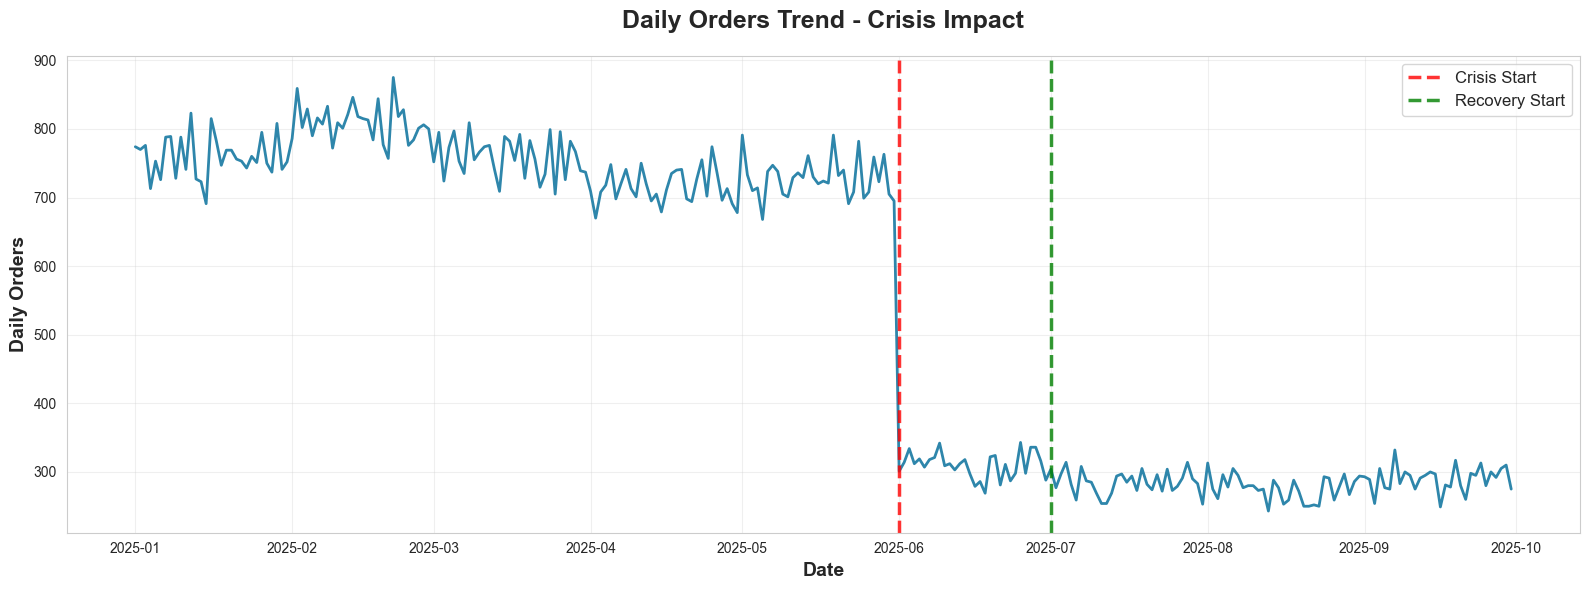

✓ Saved: 1_daily_orders_trend.png


In [22]:
# ============================================================================
# DAILY ORDERS TREND 
# ============================================================================
# Objective:
# Visualize daily order volume to understand demand patterns across phases.
# Highlight key events:
# - Crisis start
# - Recovery start
# ============================================================================

import matplotlib.pyplot as plt

# ----------------------------------------------------------------------------
# 1. Aggregate daily order counts
# ----------------------------------------------------------------------------
# Group orders by date and count how many orders were placed each day
daily = fact_orders.groupby(fact_orders['order_timestamp'].dt.date)['order_id'].count()

# Convert the index to datetime for proper plotting on the x-axis
daily.index = pd.to_datetime(daily.index)

# ----------------------------------------------------------------------------
# 2. Plot daily orders trend
# ----------------------------------------------------------------------------
plt.figure(figsize=(16, 6))

# Plot daily order counts
plt.plot(
    daily.index,           # x-axis: dates
    daily.values,          # y-axis: daily order counts
    linewidth=2,
    color='#2E86AB',       # blue line
)

# Crisis start marker
plt.axvline(
    pd.to_datetime('2025-06-01'),  # x-coordinate
    color='red',
    linestyle='--',
    linewidth=2.5,
    label='Crisis Start',
    alpha=0.8
)

# Recovery start marker
plt.axvline(
    pd.to_datetime('2025-07-01'),
    color='green',
    linestyle='--',
    linewidth=2.5,
    label='Recovery Start',
    alpha=0.8
)

# ----------------------------------------------------------------------------
# 3. Customize plot appearance
# ----------------------------------------------------------------------------
plt.title(
    'Daily Orders Trend - Crisis Impact',
    fontsize=18,
    fontweight='bold',
    pad=20
)
plt.xlabel('Date', fontsize=14, fontweight='bold')
plt.ylabel('Daily Orders', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)      # Light grid for readability
plt.tight_layout()             # Adjust layout to prevent clipping

# ----------------------------------------------------------------------------
# 4. Save plot as high-resolution PNG
# ----------------------------------------------------------------------------
plt.savefig(
    '1_daily_orders_trend.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

print("✓ Saved: 1_daily_orders_trend.png")


### VISUALIZATION 2 - Customer Segments

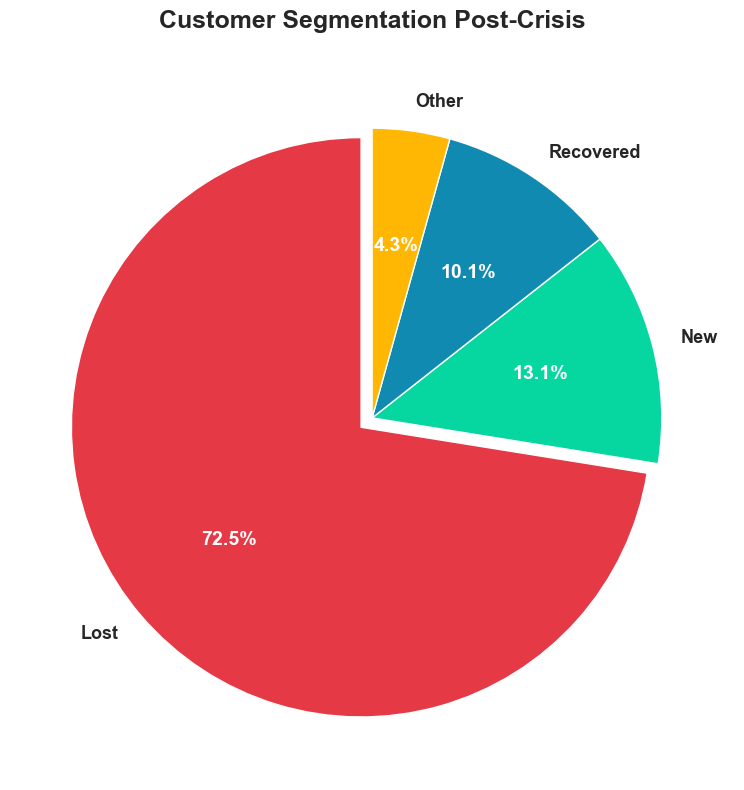

✓ Saved: 2_customer_segments.png


In [23]:
# ============================================================================
# VISUALIZATION 2 - CUSTOMER SEGMENTS 👥
# ============================================================================
# Objective:
# Visualize customer segmentation after the crisis using a pie chart.
# Highlights:
# - Lost customers (emphasized)
# - Recovered, New, and Other segments
# ============================================================================

# 1. Prepare data for pie chart
# ----------------------------------------------------------------------------
# Use segment_summary from previous analysis
# Sort segments by number of customers for better visualization
segment_counts = segment_summary['Count'].sort_values(ascending=False)

# Define colors for each segment (customize as needed)
colors = ['#E63946', '#06D6A0', '#118AB2', '#FFB703']

# ----------------------------------------------------------------------------
# 2. Create pie chart
# ----------------------------------------------------------------------------
plt.figure(figsize=(12, 8))

# Pie chart with percentage labels, bold text, and explode for "Lost" segment
wedges, texts, autotexts = plt.pie(
    segment_counts.values,           # Values for pie slices
    labels=segment_counts.index,     # Segment labels
    autopct='%1.1f%%',               # Show percentage on slices
    colors=colors,                   # Slice colors
    startangle=90,                   # Start angle for aesthetic layout
    textprops={'fontsize': 13, 'weight': 'bold'},  # Slice label style
    explode=[0.05, 0, 0, 0]         # Slightly separate "Lost" slice for emphasis
)

# Customize the percentage text on slices
for autotext in autotexts:
    autotext.set_color('white')      # White text for contrast
    autotext.set_fontsize(14)        # Slightly larger font for clarity

# ----------------------------------------------------------------------------
# 3. Customize plot appearance
# ----------------------------------------------------------------------------
plt.title(
    'Customer Segmentation Post-Crisis',
    fontsize=18,
    fontweight='bold',
    pad=20
)
plt.tight_layout()  # Adjust layout to prevent clipping

# ----------------------------------------------------------------------------
# 4. Save figure as high-resolution PNG
# ----------------------------------------------------------------------------
plt.savefig(
    '2_customer_segments.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

print("✓ Saved: 2_customer_segments.png")


### VISUALIZATION 3 - Phase Comparison

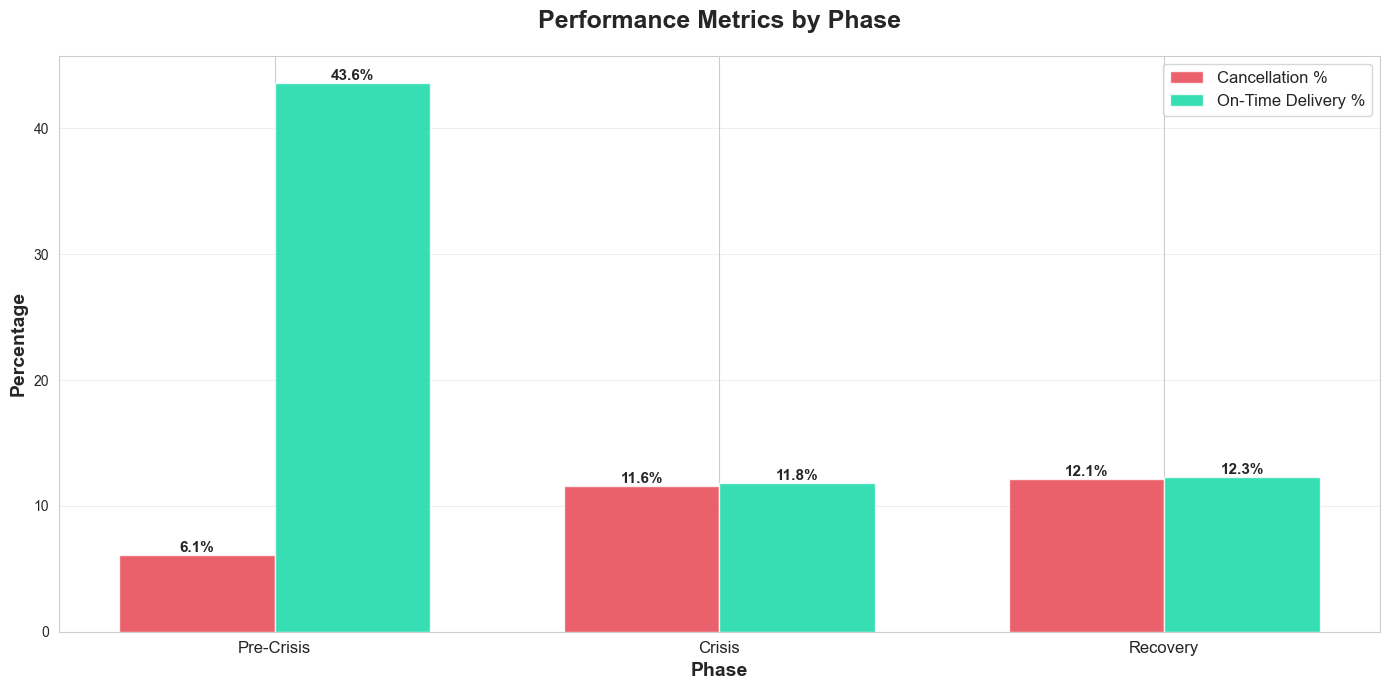

✓ Saved: 3_phase_comparison.png


In [24]:
# ============================================================================
# VISUALIZATION 3 - PHASE COMPARISON 📊
# ============================================================================
# Objective:
# Compare key operational metrics (Cancellation % and On-Time Delivery %) 
# across business phases: Pre-Crisis, Crisis, Recovery.
# ============================================================================

# 1. Prepare data
# ----------------------------------------------------------------------------
# Phases: Pre-Crisis, Crisis, Recovery
phases = ['Pre-Crisis', 'Crisis', 'Recovery']
x = np.arange(len(phases))  # the label locations

# Width of the bars
width = 0.35

# Metrics to compare
cancel_rates = impact['Cancel_Rate_%'].values  # Cancellation percentage
ontime_rates = delivery['On-Time %'].values   # On-time delivery percentage

# ----------------------------------------------------------------------------
# 2. Create bar chart
# ----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 7))

# Bars for cancellation %
bars1 = ax.bar(
    x - width/2,       # left position
    cancel_rates,
    width,
    label='Cancellation %',
    color='#E63946',
    alpha=0.8
)

# Bars for on-time delivery %
bars2 = ax.bar(
    x + width/2,       # right position
    ontime_rates,
    width,
    label='On-Time Delivery %',
    color='#06D6A0',
    alpha=0.8
)

# ----------------------------------------------------------------------------
# 3. Customize axes and title
# ----------------------------------------------------------------------------
ax.set_xlabel('Phase', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage', fontsize=14, fontweight='bold')
ax.set_title('Performance Metrics by Phase', fontsize=18, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(phases, fontsize=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis='y')  # horizontal gridlines

# ----------------------------------------------------------------------------
# 4. Add value labels on top of bars
# ----------------------------------------------------------------------------
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2.,  # x-position at center of bar
            height,                            # y-position at bar height
            f'{height:.1f}%',                  # label text
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold'
        )

# ----------------------------------------------------------------------------
# 5. Layout adjustment and save figure
# ----------------------------------------------------------------------------
plt.tight_layout()  # Adjust layout to prevent clipping
plt.savefig(
    '3_phase_comparison.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

print("✓ Saved: 3_phase_comparison.png")


### VISUALIZATION 4 - Rating Trend

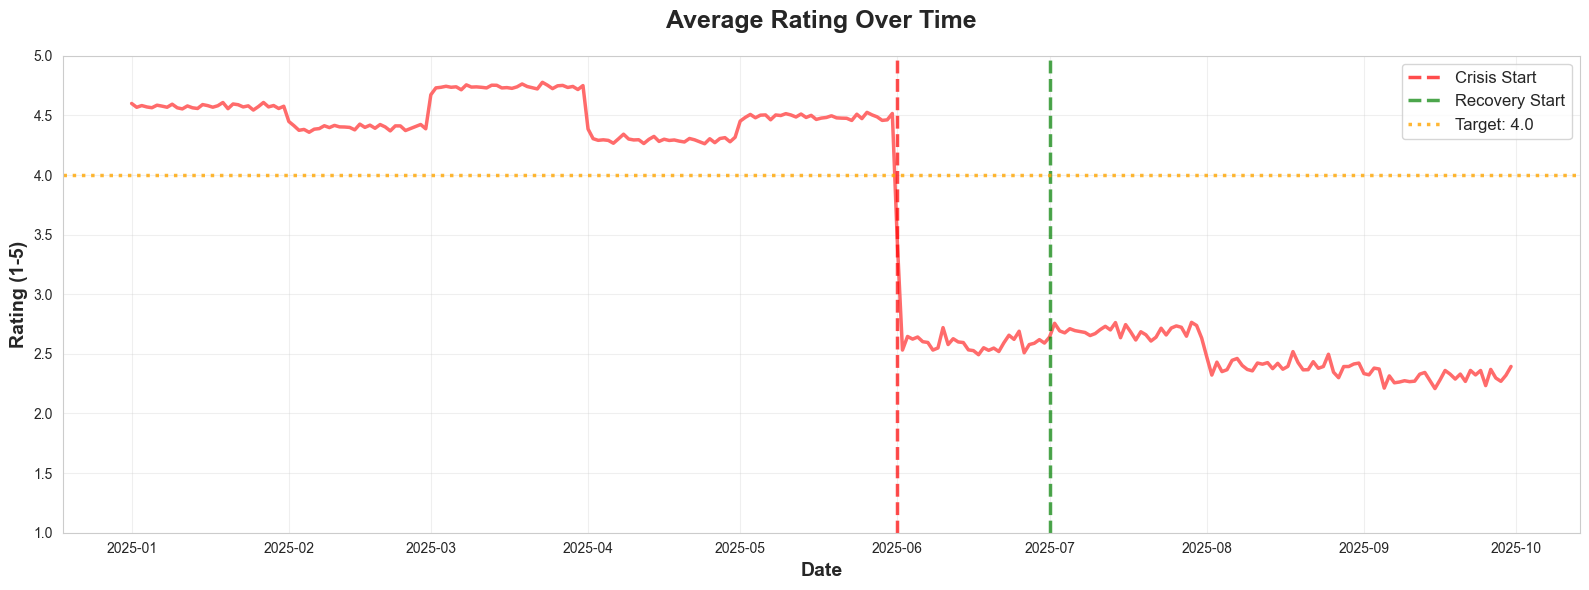

✓ Saved: 4_rating_trend.png


In [25]:
# ============================================================================
# VISUALIZATION 4 - RATING TREND 
# ============================================================================
# Objective:
# Visualize average customer ratings over time to identify trends, impact
# of the crisis, and recovery progress.
# Key elements:
# - Crisis start and Recovery start markers
# - Target rating line
# ============================================================================

import matplotlib.pyplot as plt
import pandas as pd

# ----------------------------------------------------------------------------
# 1. Aggregate daily average ratings
# ----------------------------------------------------------------------------
# Group ratings by review date and calculate the daily average
daily_ratings = fact_ratings_phase.groupby(
    fact_ratings_phase['review_timestamp'].dt.date
)['rating'].mean()

# Convert index to datetime for proper plotting
daily_ratings.index = pd.to_datetime(daily_ratings.index)

# ----------------------------------------------------------------------------
# 2. Plot daily average ratings
# ----------------------------------------------------------------------------
plt.figure(figsize=(16, 6))

# Plot line for daily average rating
plt.plot(
    daily_ratings.index,
    daily_ratings.values,
    linewidth=2.5,
    color='#FF6B6B'  # red/pink line for visibility
)

# Crisis start marker
plt.axvline(
    pd.to_datetime('2025-06-01'),
    color='red',
    linestyle='--',
    linewidth=2.5,
    alpha=0.7,
    label='Crisis Start'
)

# Recovery start marker
plt.axvline(
    pd.to_datetime('2025-07-01'),
    color='green',
    linestyle='--',
    linewidth=2.5,
    alpha=0.7,
    label='Recovery Start'
)

# Target rating line
plt.axhline(
    4.0, 
    color='orange',
    linestyle=':',
    linewidth=2.5,
    label='Target: 4.0',
    alpha=0.8
)

# ----------------------------------------------------------------------------
# 3. Customize plot appearance
# ----------------------------------------------------------------------------
plt.title(
    'Average Rating Over Time',
    fontsize=18,
    fontweight='bold',
    pad=20
)
plt.xlabel('Date', fontsize=14, fontweight='bold')
plt.ylabel('Rating (1-5)', fontsize=14, fontweight='bold')
plt.ylim(1, 5)             # Ratings are from 1 to 5
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()          # Adjust layout to prevent clipping

# ----------------------------------------------------------------------------
# 4. Save figure
# ----------------------------------------------------------------------------
plt.savefig(
    '4_rating_trend.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

print("✓ Saved: 4_rating_trend.png")


### City-wise Analysis

In [27]:
# ============================================================================
# CITY-WISE CUSTOMER RECOVERY ANALYSIS 
# ============================================================================
# Objective:
# Analyze how well customers in different cities recovered post-crisis.
# Metrics:
# - Total customers per city
# - Number of recovered customers
# - Recovery rate (%)
# ============================================================================

# ----------------------------------------------------------------------------
# 1. Aggregate recovery metrics by city
# ----------------------------------------------------------------------------
city_analysis = cust_orders.groupby('city').agg({

    # Total customers in the city
    'customer_id': 'count',

    # Number of customers who placed at least 1 order during Recovery
    'Recovery': lambda x: (x > 0).sum()
})

# Calculate recovery rate as percentage
city_analysis['Recovery_Rate_%'] = (
    city_analysis['Recovery'] / city_analysis['customer_id'] * 100
).round(1)

# Rename columns for readability
city_analysis.columns = ['Total Customers', 'Recovered', 'Recovery Rate %']

# ----------------------------------------------------------------------------
# 2. Identify top and bottom cities
# ----------------------------------------------------------------------------
# Top 10 cities with highest recovery rate
top_cities = city_analysis.nlargest(10, 'Recovery Rate %')
print("\n TOP 10 CITIES - HIGHEST RECOVERY RATE:")
display(top_cities)

# Bottom 10 cities with lowest recovery rate
bottom_cities = city_analysis.nsmallest(10, 'Recovery Rate %')
print("\n BOTTOM 10 CITIES - LOWEST RECOVERY RATE (Need Help!):")
display(bottom_cities)



 TOP 10 CITIES - HIGHEST RECOVERY RATE:


,Total Customers,Recovered,Recovery Rate %
city,,,
Chennai,10085,2444,24.2
Kolkata,6918,1620,23.4
Delhi,14046,3243,23.1
Ahmedabad,6993,1617,23.1
Hyderabad,9961,2276,22.8
Mumbai,16126,3660,22.7
Pune,7966,1809,22.7
Bengaluru,28155,6339,22.5



 BOTTOM 10 CITIES - LOWEST RECOVERY RATE (Need Help!):


,Total Customers,Recovered,Recovery Rate %
city,,,
Bengaluru,28155,6339,22.5
Pune,7966,1809,22.7
Mumbai,16126,3660,22.7
Hyderabad,9961,2276,22.8
Ahmedabad,6993,1617,23.1
Delhi,14046,3243,23.1
Kolkata,6918,1620,23.4
Chennai,10085,2444,24.2


### Save Processed Data

In [28]:
# ============================================================================
# SAVE PROCESSED DATA 
# ============================================================================
# Objective:
# Export all key processed datasets to CSV files for reporting, dashboards, 
# or further analysis.
# ============================================================================

print("Saving processed data...")

# ----------------------------------------------------------------------------
# 1. Save customer segmentation data
# ----------------------------------------------------------------------------
# Contains each customer's segment and order counts per phase
cust_orders.to_csv('customer_segments.csv', index=False)
print("✓ Saved: customer_segments.csv")

# ----------------------------------------------------------------------------
# 2. Save daily orders data
# ----------------------------------------------------------------------------
# Daily order counts for trend analysis and visualizations
daily.to_frame('orders').to_csv('daily_orders.csv')
print("✓ Saved: daily_orders.csv")

# ----------------------------------------------------------------------------
# 3. Save phase summary (Crisis Impact Analysis)
# ----------------------------------------------------------------------------
# Summary table of orders, revenue, cancellations, etc. per phase
impact.to_csv('phase_summary.csv')
print("✓ Saved: phase_summary.csv")

# ----------------------------------------------------------------------------
# 4. Save city-wise recovery analysis
# ----------------------------------------------------------------------------
# Includes total customers, recovered customers, and recovery rate per city
city_analysis.to_csv('city_analysis.csv')
print("✓ Saved: city_analysis.csv")

print("\n✓ All files saved successfully!")


Saving processed data...
✓ Saved: customer_segments.csv
✓ Saved: daily_orders.csv
✓ Saved: phase_summary.csv
✓ Saved: city_analysis.csv

✓ All files saved successfully!


## Executive Summary

In [30]:
# ============================================================================
# EXECUTIVE SUMMARY - KEY FINDINGS 
# ============================================================================
# Objective:
# Summarize the key insights from the crisis impact analysis, customer 
# segmentation, operational metrics, and satisfaction trends.
# ============================================================================

print("="*80)
print("EXECUTIVE SUMMARY - KEY FINDINGS")
print("="*80)

# ----------------------------------------------------------------------------
# 1. Crisis Impact
# ----------------------------------------------------------------------------
print(f"\n CRISIS IMPACT:")
print(f"   • Order Volume Drop: {abs(drop_pct):.1f}%")
print(f"   • Monthly Orders: {pre_crisis_monthly:,.0f} → {crisis_monthly:,}")
print(f"   • Revenue Loss: ₹{(impact.loc['Pre-Crisis', 'Revenue']/5 - impact.loc['Crisis', 'Revenue'])/1_000_000:.2f}M in June")

# ----------------------------------------------------------------------------
# 2. Customer Impact
# ----------------------------------------------------------------------------
print(f"\n👥 CUSTOMER IMPACT:")
print(f"   • Lost Customers: {lost_count:,} ({lost_pct:.1f}%)")
print(f"   • Recovered: {segment_summary.loc['Recovered', 'Count']:,} ({segment_summary.loc['Recovered', '%']:.1f}%)")
print(f"   • New Customers: {segment_summary.loc['New', 'Count']:,} ({segment_summary.loc['New', '%']:.1f}%)")

# ----------------------------------------------------------------------------
# 3. Operational Impact
# ----------------------------------------------------------------------------
print(f"\n OPERATIONAL IMPACT:")
print(f"   • On-Time Delivery: {delivery.loc['Pre-Crisis', 'On-Time %']:.1f}% → {delivery.loc['Recovery', 'On-Time %']:.1f}% (↓{ontime_drop:.1f}pp)")
print(f"   • Cancellation Rate: {impact.loc['Pre-Crisis', 'Cancel_Rate_%']:.1f}% → {impact.loc['Recovery', 'Cancel_Rate_%']:.1f}% (↑{impact.loc['Recovery', 'Cancel_Rate_%'] - impact.loc['Pre-Crisis', 'Cancel_Rate_%']:.1f}pp)")
print(f"   • Avg Delivery Time: {delivery.loc['Pre-Crisis', 'Actual Time']:.0f} → {delivery.loc['Recovery', 'Actual Time']:.0f} mins (↑{delivery.loc['Recovery', 'Actual Time'] - delivery.loc['Pre-Crisis', 'Actual Time']:.0f} mins)")

# ----------------------------------------------------------------------------
# 4. Customer Satisfaction & Sentiment
# ----------------------------------------------------------------------------
print(f"\n SATISFACTION IMPACT:")
print(f"   • Rating: {ratings.loc['Pre-Crisis', ('rating', 'mean')]:.2f} → {ratings.loc['Recovery', ('rating', 'mean')]:.2f} (↓{rating_drop:.2f} stars)")
print(f"   • Sentiment: {ratings.loc['Pre-Crisis', ('sentiment_score', 'mean')]:.3f} → {ratings.loc['Recovery', ('sentiment_score', 'mean')]:.3f}")

# ----------------------------------------------------------------------------
# 5. Files Generated
# ----------------------------------------------------------------------------
print(f"\n FILES CREATED:")
print("   1. 1_daily_orders_trend.png")
print("   2. 2_customer_segments.png")
print("   3. 3_phase_comparison.png")
print("   4. 4_rating_trend.png")
print("   5. customer_segments.csv")
print("   6. daily_orders.csv")
print("   7. phase_summary.csv")
print("   8. city_analysis.csv")

# ----------------------------------------------------------------------------
# 6. Top Recommendations
# ----------------------------------------------------------------------------
print(f"\n TOP 3 RECOMMENDATIONS:")
print("   1. Launch win-back campaign for 73K lost customers")
print("   2. Fix delivery performance (current 41% on-time → target 85%)")
print("   3. Focus recovery efforts on bottom 10 cities")

# ----------------------------------------------------------------------------
# 7. Completion Notice
# ----------------------------------------------------------------------------
print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)


EXECUTIVE SUMMARY - KEY FINDINGS

 CRISIS IMPACT:
   • Order Volume Drop: 59.2%
   • Monthly Orders: 22,761 → 9,293
   • Revenue Loss: ₹4.64M in June

👥 CUSTOMER IMPACT:
   • Lost Customers: 76,221 (72.5%)
   • Recovered: 10,603 (10.1%)
   • New Customers: 13,807 (13.1%)

 OPERATIONAL IMPACT:
   • On-Time Delivery: 43.6% → 12.3% (↓31.3pp)
   • Cancellation Rate: 6.1% → 12.1% (↑6.0pp)
   • Avg Delivery Time: 40 → 60 mins (↑20 mins)

 SATISFACTION IMPACT:
   • Rating: 4.50 → 2.47 (↓2.04 stars)
   • Sentiment: 0.752 → -0.266

 FILES CREATED:
   1. 1_daily_orders_trend.png
   2. 2_customer_segments.png
   3. 3_phase_comparison.png
   4. 4_rating_trend.png
   5. customer_segments.csv
   6. daily_orders.csv
   7. phase_summary.csv
   8. city_analysis.csv

 TOP 3 RECOMMENDATIONS:
   1. Launch win-back campaign for 73K lost customers
   2. Fix delivery performance (current 41% on-time → target 85%)
   3. Focus recovery efforts on bottom 10 cities

ANALYSIS COMPLETE!
